# **Project Name : Portuguese Bank**

### **Problem Statement**

This dataset is about the direct phone call marketing campaigns, which aim to promote term deposits among existing customers, by a Portuguese banking institution from May 2008 to November 2010. 

In [116]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [117]:
data = pd.read_csv('bank-full.csv')

In [118]:
data

,age,job,education,default,balance,housing,loan,duration,campaign,pdays,previous,y
0,58,management,tertiary,no,2143,yes,no,261,1,-1,0,no
1,44,technician,secondary,no,29,yes,no,151,1,-1,0,no
2,33,entrepreneur,secondary,no,2,yes,yes,76,1,-1,0,no
3,47,blue-collar,unknown,no,1506,yes,no,92,1,-1,0,no
4,33,unknown,unknown,no,1,no,no,198,1,-1,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,tertiary,no,825,no,no,977,3,-1,0,yes
45207,71,retired,primary,no,1729,no,no,456,2,-1,0,yes
45208,72,retired,secondary,no,5715,no,no,1127,5,184,3,yes
45209,57,blue-collar,secondary,no,668,no,no,508,4,-1,0,no


### **Domain Analysis**

#### **1. age**

- Represents the age of the customer.
- Older customers may prefer safe investment products like term deposits.
- Impact on subscription: MEDIUM–HIGH

---

#### **2. job**

- Indicates customer occupation (admin, technician, retired, student, etc.).
- Income level and financial stability vary by profession.
- Impact on subscription: HIGH

---

#### **3. education**

- Customer’s education level.
- Highly educated customers may better understand financial benefits.
- Impact: MEDIUM–HIGH

---

#### **4. default**

- Indicates if the customer has credit in default.
- Customers with defaults may have financial stress and lower investment capacity.
- Impact: HIGH

---

#### **5. balance**

- Represents customer’s average yearly account balance. 
- Higher balances indicate better financial capacity and higher likelihood of subscribing to term deposits.
- Impact: VERY HIGH

---

#### **6. housing**

- Indicates if the customer has a housing loan.
- Customers with housing loans may have limited disposable income.
- Impact: MEDIUM

---

#### **7. loan**

- Indicates if the customer has a personal loan.
- Existing loans may reduce likelihood of additional financial commitments.
- Impact: MEDIUM

---

#### **8. duration**

- Call duration in seconds.
- Longer calls often indicate higher engagement.
- However, this variable is known only after the call and causes data leakage.
- Impact (if used): VERY HIGH
    
---

#### **9. campaign**

- Number of contacts made during current campaign.
- Too many calls may irritate customers and reduce response rate.
- Impact: HIGH

---

#### **10. pdays**

- Number of days since last contact.
- 999 means never contacted before.
- Recently contacted customers may respond differently.
- Impact: HIGH

---

#### **11. pdays**

- Number of days since last contact.
- 999 means never contacted before.
- Recently contacted customers may respond differently.
- Impact: HIGH

---

#### **12. y**

- Indicates whether the customer subscribed to a term deposit.

- Values:
- Yes → Subscribed
- No → Did not subscribe

### **Basic Checks**

In [119]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   education  45211 non-null  object
 3   default    45211 non-null  object
 4   balance    45211 non-null  int64 
 5   housing    45211 non-null  object
 6   loan       45211 non-null  object
 7   duration   45211 non-null  int64 
 8   campaign   45211 non-null  int64 
 9   pdays      45211 non-null  int64 
 10  previous   45211 non-null  int64 
 11  y          45211 non-null  object
dtypes: int64(6), object(6)
memory usage: 4.1+ MB


In [120]:
data.isnull().sum()

age          0
job          0
education    0
default      0
balance      0
housing      0
loan         0
duration     0
campaign     0
pdays        0
previous     0
y            0
dtype: int64

In [121]:
data.describe()

,age,balance,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,4918.000000,63.000000,871.000000,275.000000


In [122]:
data.head()

,age,job,education,default,balance,housing,loan,duration,campaign,pdays,previous,y
0,58,management,tertiary,no,2143,yes,no,261,1,-1,0,no
1,44,technician,secondary,no,29,yes,no,151,1,-1,0,no
2,33,entrepreneur,secondary,no,2,yes,yes,76,1,-1,0,no
3,47,blue-collar,unknown,no,1506,yes,no,92,1,-1,0,no
4,33,unknown,unknown,no,1,no,no,198,1,-1,0,no


In [123]:
data.tail()

,age,job,education,default,balance,housing,loan,duration,campaign,pdays,previous,y
45206,51,technician,tertiary,no,825,no,no,977,3,-1,0,yes
45207,71,retired,primary,no,1729,no,no,456,2,-1,0,yes
45208,72,retired,secondary,no,5715,no,no,1127,5,184,3,yes
45209,57,blue-collar,secondary,no,668,no,no,508,4,-1,0,no
45210,37,entrepreneur,secondary,no,2971,no,no,361,2,188,11,no


### **EDA (Exploratory Data Analysis)**

#### **Univariate Analysis**

In [124]:
cal_data=['job','education','default','housing','loan']
numerical_data=['balance']

In [125]:
num_data=['age','balance','duration','campaign','pdays','previous']

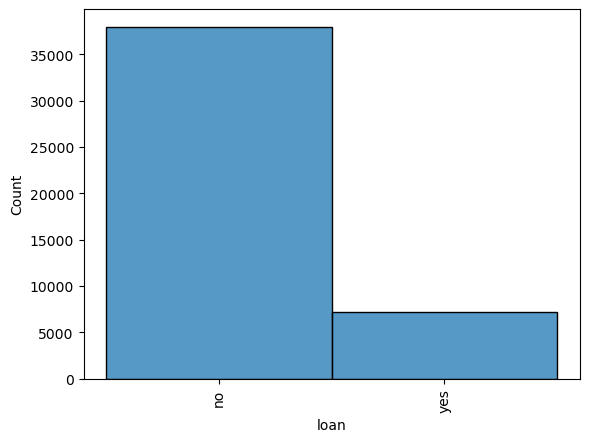

In [126]:
sns.histplot(x='loan',data=data)
plt.xticks(rotation=90)
plt.show()

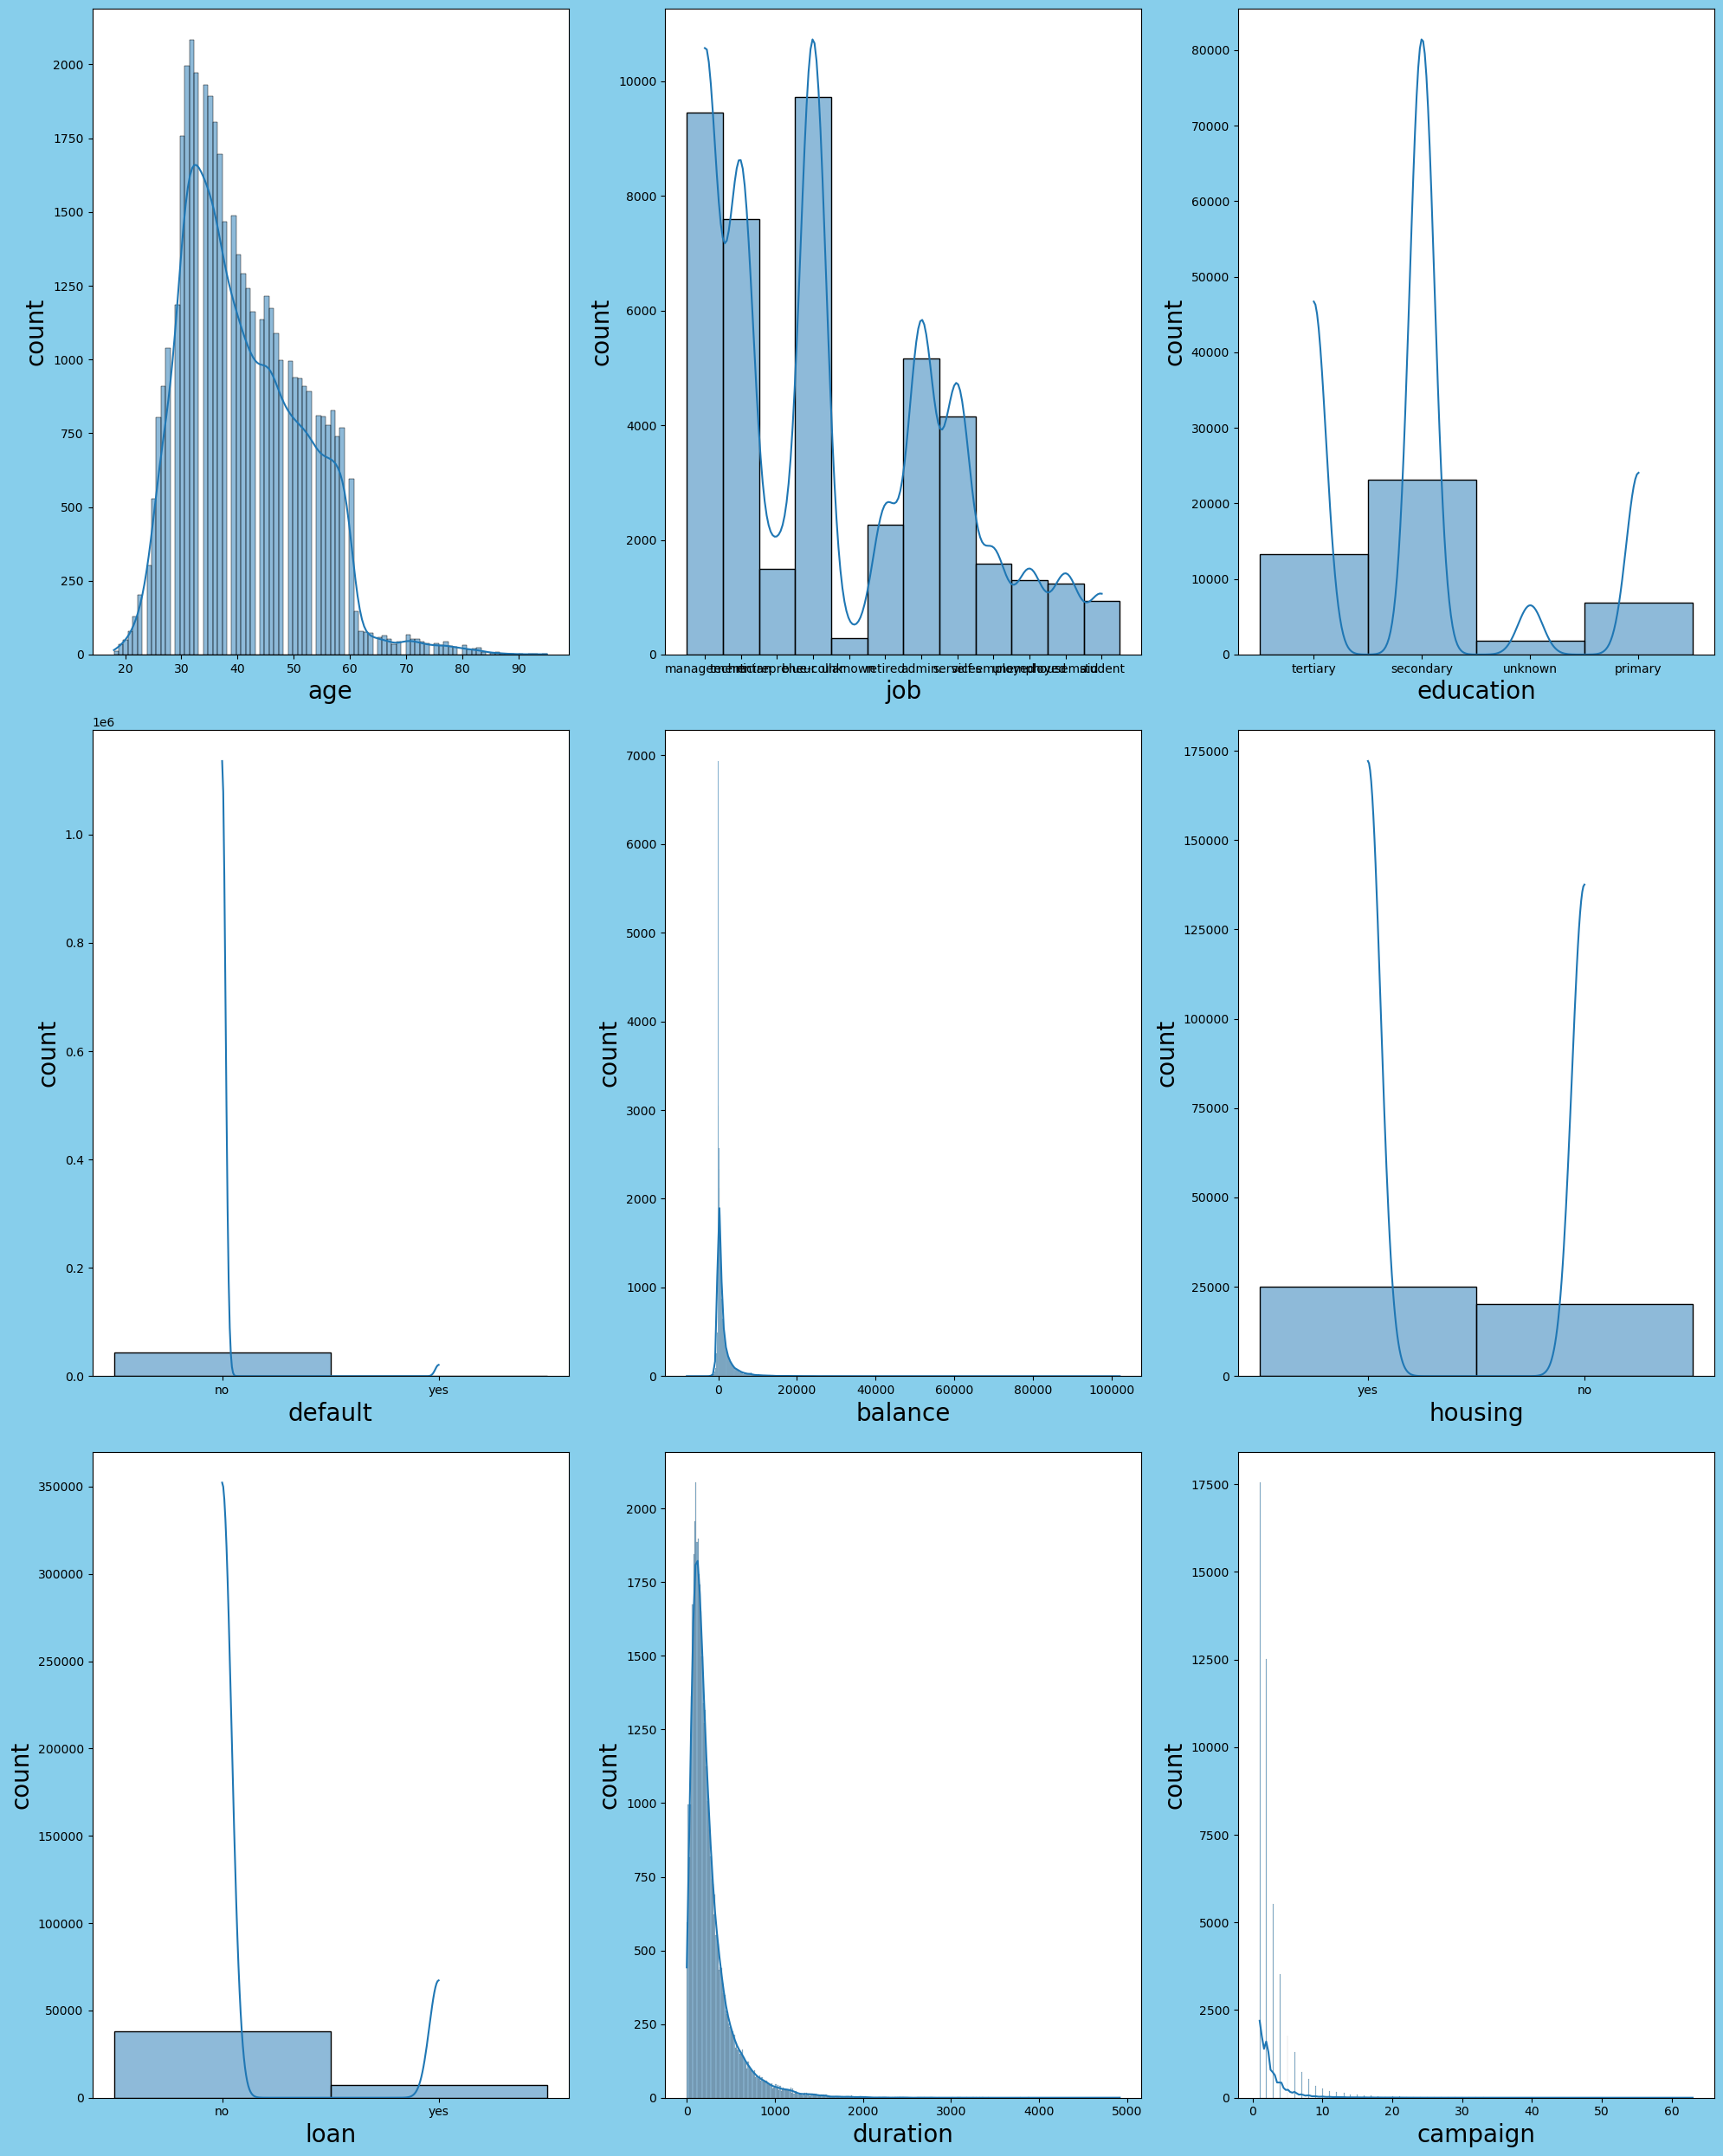

In [127]:
plt.figure(figsize=(20,25),facecolor='skyblue')
plotnumber=1

for column in data.columns:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.histplot(data[column],kde=1)
        plt.xlabel(column,fontsize=20)

        plt.ylabel('count',fontsize=20)
    plotnumber+=1
plt.tight_layout()
plt.show()

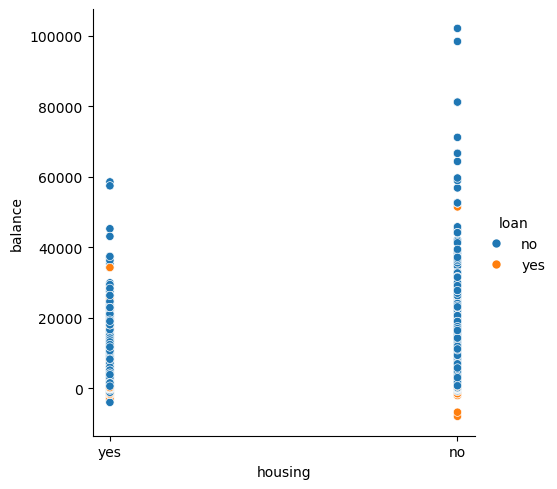

In [134]:
# Multivariate Analysis

sns.relplot(x='housing',y='balance',hue='loan',data=data)
plt.show()

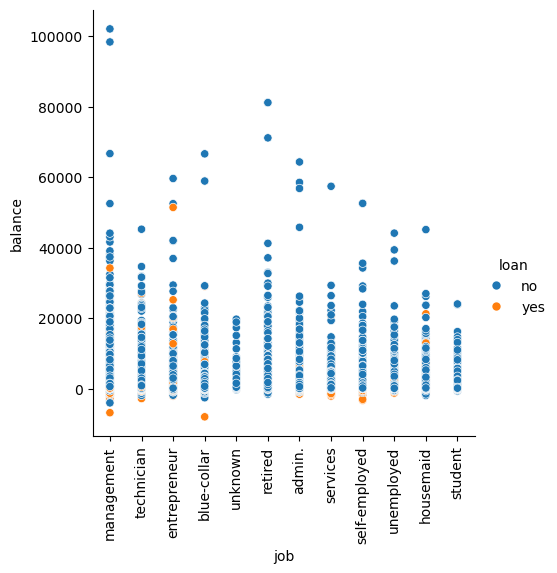

In [135]:
sns.relplot(x='job',y='balance',hue='loan',data=data)
plt.xticks(rotation=90)
plt.show()

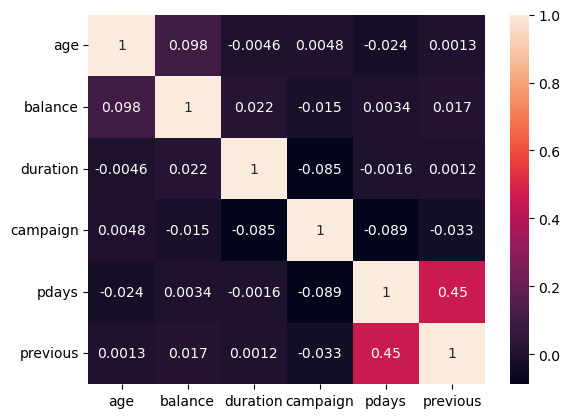

In [136]:
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

In [137]:
data.isnull().sum()

age          0
job          0
education    0
default      0
balance      0
housing      0
loan         0
duration     0
campaign     0
pdays        0
previous     0
y            0
dtype: int64

#### **Outlier**

A boxplot shows the distribution of each column and helps identify extreme values (points far away from normal range).
Outliers are values that are too high or too low compared to other data points and can affect model performance.

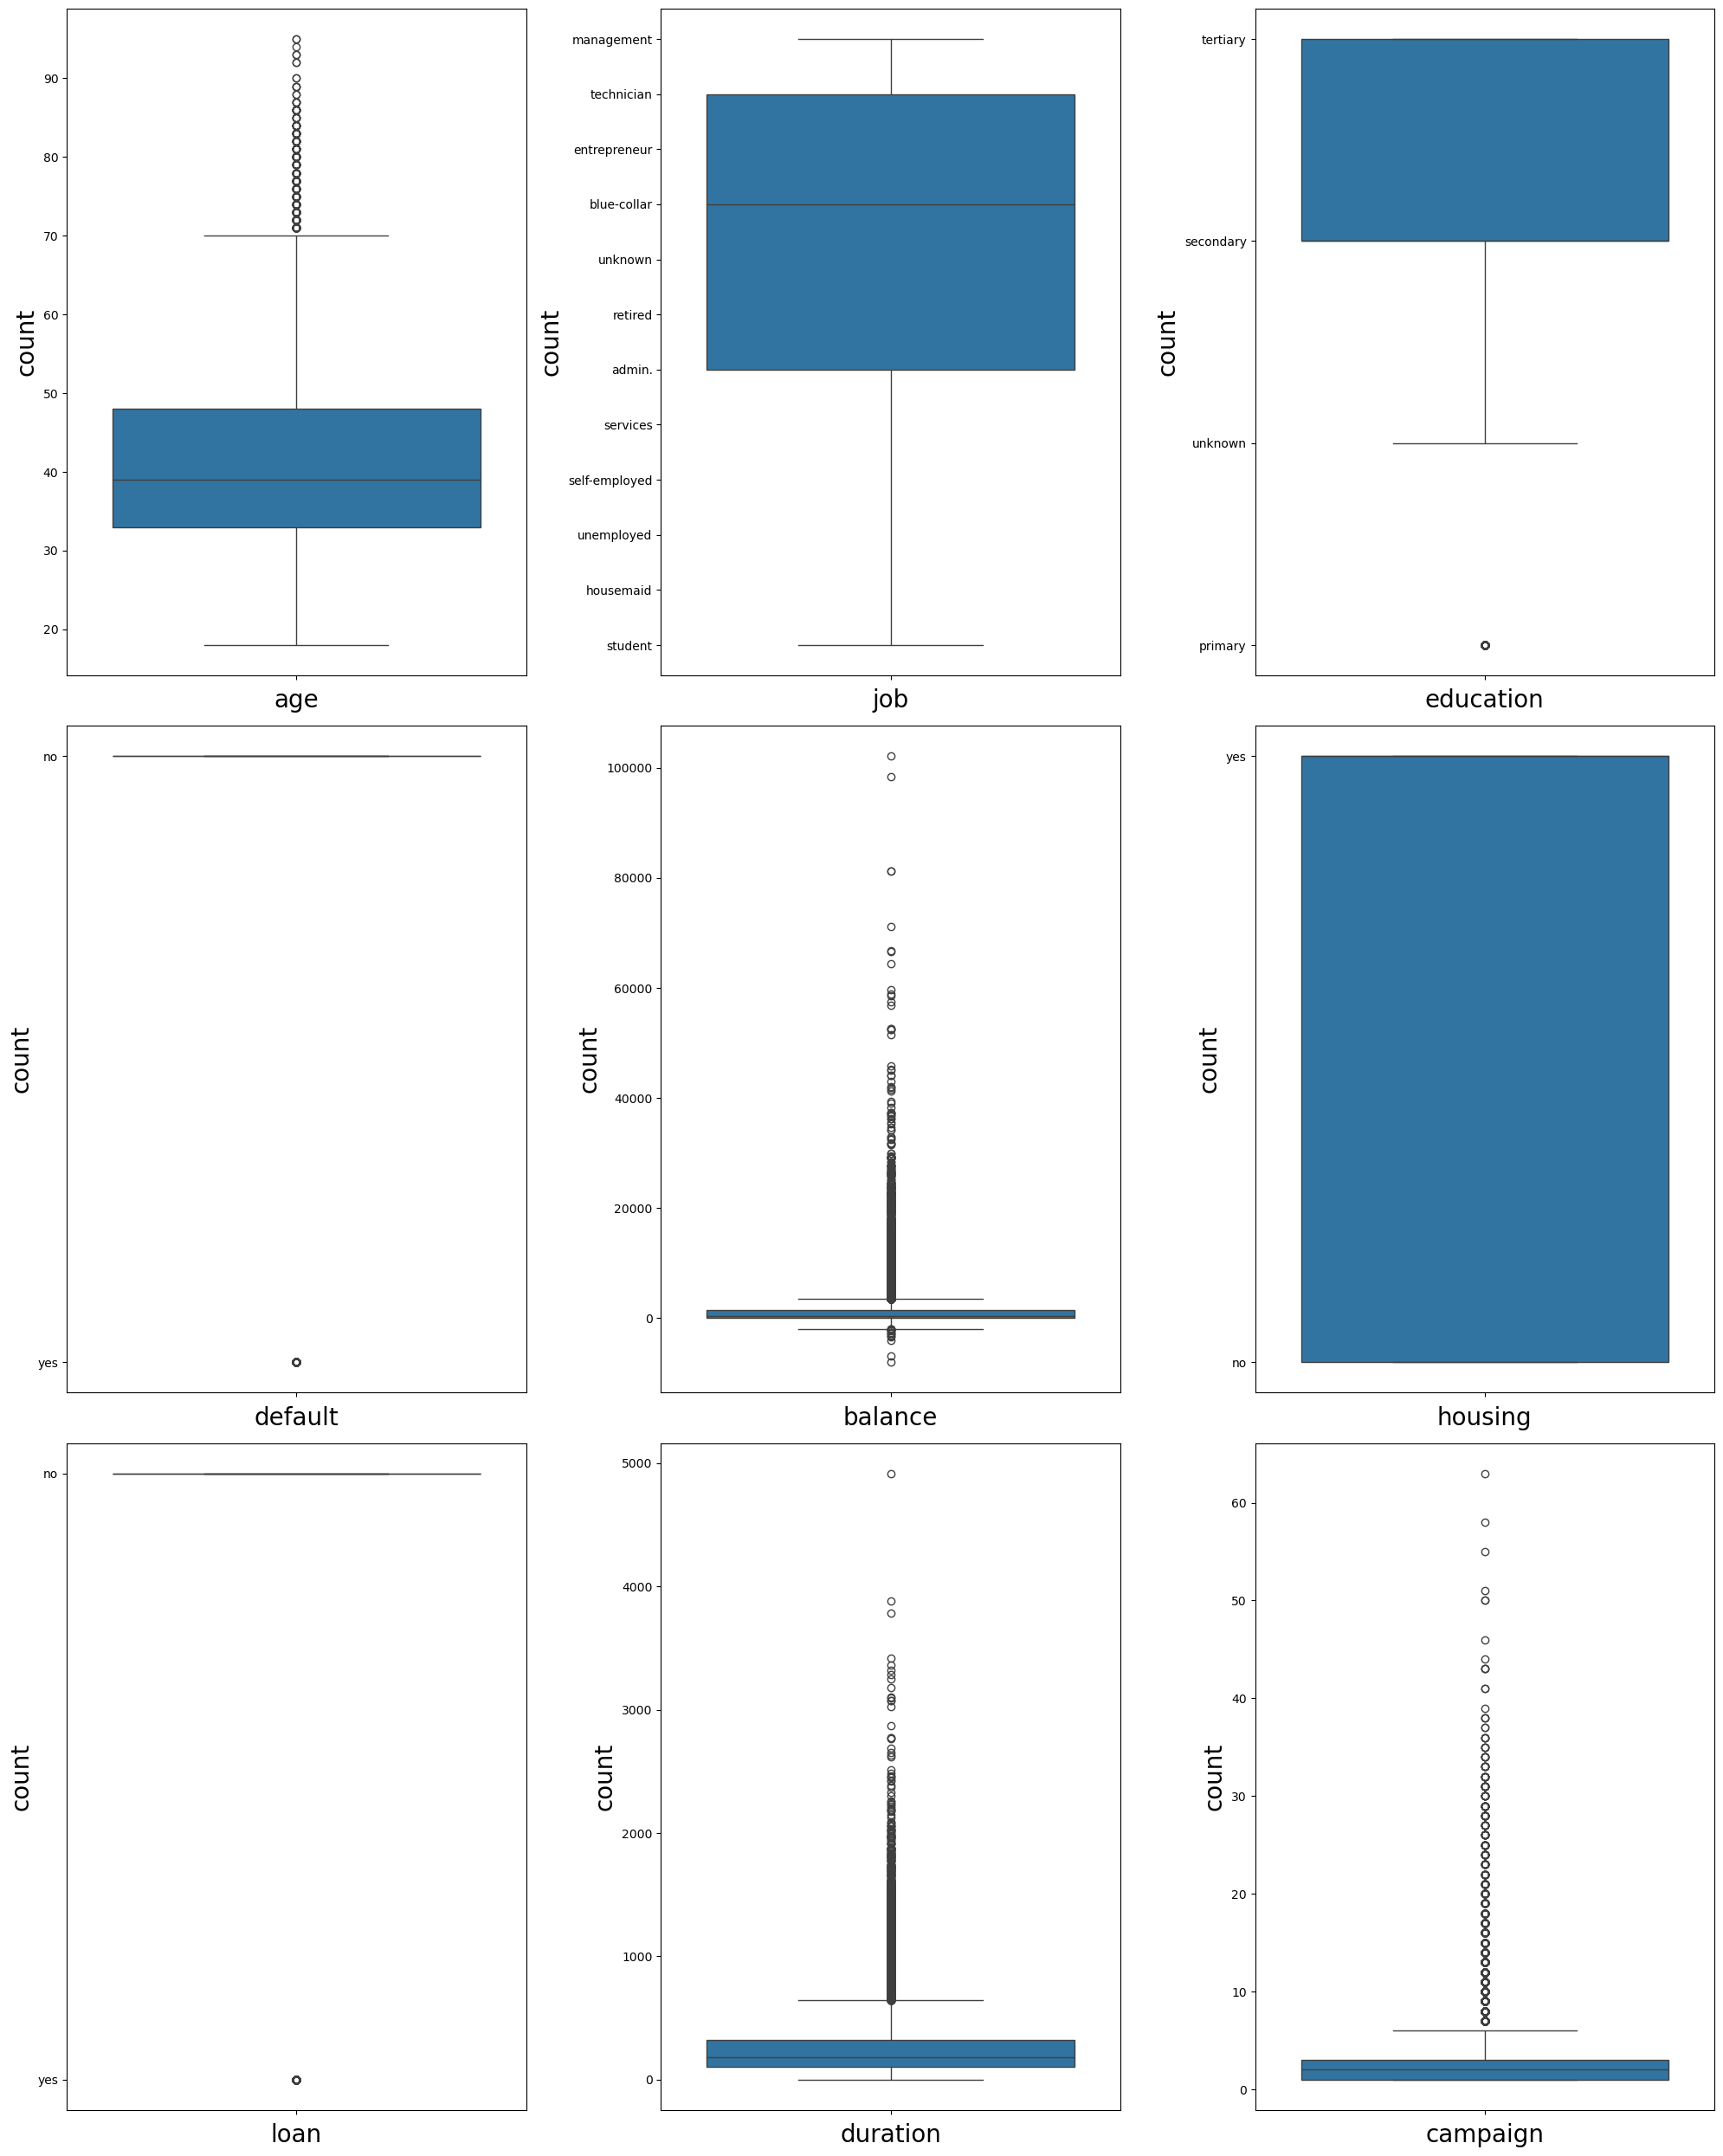

In [138]:
plt.figure(figsize=(20,25),facecolor='white')
plotnumber=1

for column in data:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.boxplot(data[column])
        plt.xlabel(column,fontsize=20)
        plt.ylabel('count',fontsize=20)
    plotnumber+=1
plt.tight_layout()
plt.show()

In [139]:
# scaling the data
binary_cols=['default','loan','housing','y']

In [140]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in binary_cols:
    data[col]= le.fit_transform(data[col])

In [141]:
# MinMax Scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data[num_data]= scaler.fit_transform(data[num_data])

### **Feature Selection**

In [142]:
data[num_data]

,age,balance,duration,campaign,pdays,previous
0,0.519481,0.092259,0.053070,0.000000,0.000000,0.000000
1,0.337662,0.073067,0.030704,0.000000,0.000000,0.000000
2,0.194805,0.072822,0.015453,0.000000,0.000000,0.000000
3,0.376623,0.086476,0.018707,0.000000,0.000000,0.000000
4,0.194805,0.072812,0.040260,0.000000,0.000000,0.000000
...,...,...,...,...,...,...
45206,0.428571,0.080293,0.198658,0.032258,0.000000,0.000000
45207,0.688312,0.088501,0.092721,0.016129,0.000000,0.000000
45208,0.701299,0.124689,0.229158,0.064516,0.212156,0.010909
45209,0.506494,0.078868,0.103294,0.048387,0.000000,0.000000


In [143]:
data=data.dropna(axis=1,how='all')

In [144]:
num_data=['age','balance','campaign','pdays']

In [145]:
data[num_data]

,age,balance,campaign,pdays
0,0.519481,0.092259,0.000000,0.000000
1,0.337662,0.073067,0.000000,0.000000
2,0.194805,0.072822,0.000000,0.000000
3,0.376623,0.086476,0.000000,0.000000
4,0.194805,0.072812,0.000000,0.000000
...,...,...,...,...
45206,0.428571,0.080293,0.032258,0.000000
45207,0.688312,0.088501,0.016129,0.000000
45208,0.701299,0.124689,0.064516,0.212156
45209,0.506494,0.078868,0.048387,0.000000


In [146]:
data1=pd.DataFrame(data[num_data])

In [147]:
data[binary_cols]=data[binary_cols].replace({'no':0,'yes':1})
data[binary_cols]

final_df=pd.concat([data[num_data],data[binary_cols]],axis=1)

### **Logistic Regression**

In [148]:
# We are creating dependent and independent variable
data[binary_cols]
# num_df=data[num_data]

,default,loan,housing,y
0,0,0,1,0
1,0,0,1,0
2,0,1,1,0
3,0,0,1,0
4,0,0,0,0
...,...,...,...,...
45206,0,0,0,1
45207,0,0,0,1
45208,0,0,0,1
45209,0,0,0,0


In [149]:
x= final_df.iloc[:,:-1]
y= final_df.iloc[:,-1]
x

,age,balance,campaign,pdays,default,loan,housing
0,0.519481,0.092259,0.000000,0.000000,0,0,1
1,0.337662,0.073067,0.000000,0.000000,0,0,1
2,0.194805,0.072822,0.000000,0.000000,0,1,1
3,0.376623,0.086476,0.000000,0.000000,0,0,1
4,0.194805,0.072812,0.000000,0.000000,0,0,0
...,...,...,...,...,...,...,...
45206,0.428571,0.080293,0.032258,0.000000,0,0,0
45207,0.688312,0.088501,0.016129,0.000000,0,0,0
45208,0.701299,0.124689,0.064516,0.212156,0,0,0
45209,0.506494,0.078868,0.048387,0.000000,0,0,0


In [150]:
y

0        0
1        0
2        0
3        0
4        0
        ..
45206    1
45207    1
45208    1
45209    0
45210    0
Name: y, Length: 45211, dtype: int64

### **Training Model**

In [151]:
# Creating testing and training model
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=45)
x_train

,age,balance,campaign,pdays,default,loan,housing
2184,0.324675,0.075300,0.048387,0.0,0,0,1
41191,0.194805,0.150101,0.000000,0.0,0,0,0
26626,0.194805,0.078532,0.016129,0.0,0,0,0
15370,0.168831,0.108946,0.000000,0.0,0,0,1
12322,0.545455,0.085051,0.016129,0.0,0,1,0
...,...,...,...,...,...,...,...
32469,0.272727,0.074438,0.000000,0.0,0,0,1
16317,0.389610,0.077161,0.000000,0.0,0,1,0
12895,0.155844,0.073575,0.000000,0.0,0,1,1
6012,0.129870,0.078033,0.048387,0.0,0,1,1


In [152]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()
lr.fit(x_train,y_train) # training

LogisticRegression()

In [153]:
y_pred_lr=lr.predict(x_test)

In [154]:
y_pred_lr

array([0, 0, 0, ..., 0, 0, 0])

In [155]:
y_pred_proba=lr.predict_proba(x_test)

In [156]:
y_pred_proba

array([[0.95705192, 0.04294808],
       [0.96233173, 0.03766827],
       [0.85648575, 0.14351425],
       ...,
       [0.92535348, 0.07464652],
       [0.90156363, 0.09843637],
       [0.89427935, 0.10572065]])

In [157]:
data.y.value_counts()

y
0    39922
1     5289
Name: count, dtype: int64

### **Model Evaluation**

In [158]:
from sklearn.metrics import (
confusion_matrix,
recall_score,
precision_score,
accuracy_score,
f1_score,
classification_report,
roc_auc_score)
cm=confusion_matrix(y_test,y_pred_lr)
print(cm)

[[9988   14]
 [1295    6]]


In [159]:
y_test

6367     0
8215     0
19376    0
37998    0
41843    0
        ..
10140    0
34283    0
14605    0
43607    1
32996    0
Name: y, Length: 11303, dtype: int64

In [160]:
recall=recall_score(y_test,y_pred_lr,average='weighted')
recall

0.8841900380429975

In [161]:
f1score=f1_score(y_test,y_pred_lr,average='weighted')
f1score

0.8315233337994848

In [162]:
precision=precision_score(y_test,y_pred_lr,average='weighted')
precision

0.8178648196850181

In [163]:
cr=classification_report(y_test,y_pred_lr)
print(cr)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     10002
           1       0.30      0.00      0.01      1301

    accuracy                           0.88     11303
   macro avg       0.59      0.50      0.47     11303
weighted avg       0.82      0.88      0.83     11303



### **Random Forest**

In [164]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()

In [165]:
# Training the model
rf_train=rf.fit(x_train,y_train)

In [166]:
# Making the predict
y_pred_rf=rf.predict(x_test)
print(y_pred_rf)

[0 0 0 ... 0 1 0]


In [167]:
y_pred_proba_rf=rf.predict_proba(x_test)
print(y_pred_proba)

[[0.95705192 0.04294808]
 [0.96233173 0.03766827]
 [0.85648575 0.14351425]
 ...
 [0.92535348 0.07464652]
 [0.90156363 0.09843637]
 [0.89427935 0.10572065]]


In [168]:
precision_rf=precision_score(y_test,y_pred_rf,average='weighted')
print(precision_rf)

0.8386129286756058


In [169]:
recall_rf=recall_score(y_test,y_pred_rf,average='weighted')
print(recall_rf)

0.8670264531540299


In [170]:
f1_score_rf=f1_score(y_test,y_pred_rf,average='weighted')
print(f1_score_rf)

0.8493950016024817


In [171]:
confusion_matrix_rf=confusion_matrix(y_test,y_pred_rf)
print(confusion_matrix_rf)

[[9546  456]
 [1047  254]]


In [172]:
classification_report_rf=classification_report(y_test,y_pred_rf)
print(classification_report_rf)

              precision    recall  f1-score   support

           0       0.90      0.95      0.93     10002
           1       0.36      0.20      0.25      1301

    accuracy                           0.87     11303
   macro avg       0.63      0.57      0.59     11303
weighted avg       0.84      0.87      0.85     11303



### **Feature Information**

In [173]:
feature_importance=pd.DataFrame({
    'feature':x_train.columns,
    'importance':rf.feature_importances_
}).sort_values(by='importance',ascending=False)
feature_importance.head(10)

,feature,importance
1,balance,0.548999
0,age,0.218065
3,pdays,0.140487
2,campaign,0.051266
6,housing,0.030652
5,loan,0.008945
4,default,0.001586


### **XGBoost**

In [174]:
pip install xgboost

In [175]:
from xgboost import XGBClassifier

In [176]:
# Creating Model
rf=RandomForestClassifier(
    n_estimators=100, # Number of decision trees
    random_state=42,
    class_weight='balanced') 

In [177]:
xgb=XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])
)

In [178]:
# Training Model
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

### **Testing**

In [179]:
y_pred_xgb=xgb.predict(x_test)
print(y_pred_xgb)

[0 0 0 ... 0 1 0]


In [180]:
y_pred_proba_xgb=xgb.predict_proba(x_test)
print(y_pred_proba_xgb)

[[0.63195294 0.36804706]
 [0.75572526 0.24427475]
 [0.675795   0.32420498]
 ...
 [0.7922502  0.20774977]
 [0.11000472 0.8899953 ]
 [0.59790456 0.40209544]]


In [181]:
cf_xgb=confusion_matrix(y_test,y_pred_xgb)
print(cf_xgb)

[[7969 2033]
 [ 600  701]]


In [182]:
precision_score_xgb=precision_score(y_test,y_pred_xgb,average='weighted')
print(precision_score_xgb)

0.8524497136018135


In [183]:
recall_score_xgb=recall_score(y_test,y_pred_xgb,average='weighted')
print(recall_score_xgb)

0.7670529947801469


In [184]:
f1_score_xgb=recall_score(y_test,y_pred_xgb,average='weighted')
print(f1_score_xgb)

0.7670529947801469


In [185]:
classification_report_xgb=classification_report(y_test,y_pred_xgb)
print(classification_report_xgb)

              precision    recall  f1-score   support

           0       0.93      0.80      0.86     10002
           1       0.26      0.54      0.35      1301

    accuracy                           0.77     11303
   macro avg       0.59      0.67      0.60     11303
weighted avg       0.85      0.77      0.80     11303



### **SVM**

In [186]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [187]:
# Creating Model
scaler = StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

In [188]:
svm_model=SVC(kernel='rbf',gamma='scale',C=1,random_state=45)

In [189]:
# Training the data
svm_model.fit(x_train_scaled,y_train)

SVC(C=1, random_state=45)

In [190]:
y_pred_svm=svm_model.predict(x_test_scaled)

In [191]:
# Evaluate Model
accuracy_score_svm=accuracy_score(y_test,y_pred_svm)
print(accuracy_score_svm)

0.8848093426523932


In [192]:
confusion_matrix_svm=confusion_matrix(y_test,y_pred_svm)
print(confusion_matrix_svm)

[[9999    3]
 [1299    2]]


In [193]:
classification_report_svm=classification_report(y_test,y_pred_svm)
print(classification_report_svm)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     10002
           1       0.40      0.00      0.00      1301

    accuracy                           0.88     11303
   macro avg       0.64      0.50      0.47     11303
weighted avg       0.83      0.88      0.83     11303



### **KNN**

In [194]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [195]:
# Creating the model
scaler = StandardScaler()

x_train_scaled_knn = scaler.fit_transform(x_train)
x_test_scaled_knn = scaler.transform(x_test)

In [196]:
knn = KNeighborsClassifier(n_neighbors=5)

In [197]:
# Training the model
knn.fit(x_train_scaled_knn,y_train)

KNeighborsClassifier()

In [198]:
# Testing the model
y_pred_knn = knn.predict(x_test_scaled_knn)

In [199]:
# Evaluation of model
accuracy_score_knn=accuracy_score(y_test,y_pred_knn)
print(accuracy_score_knn)

0.8758736618596833


In [200]:
confusion_matrix_knn=confusion_matrix(y_test,y_pred_knn)
print(confusion_matrix_knn)

[[9704  298]
 [1105  196]]


In [201]:
classification_report_knn=classification_report(y_test,y_pred_knn)
print(classification_report_knn)

              precision    recall  f1-score   support

           0       0.90      0.97      0.93     10002
           1       0.40      0.15      0.22      1301

    accuracy                           0.88     11303
   macro avg       0.65      0.56      0.58     11303
weighted avg       0.84      0.88      0.85     11303



### **Comparing all the Algorithm**

This code compares multiple classification models using key evaluation metrics like Accuracy, Precision, Recall, and F1-Score. The metrics are extracted for the positive class (customers who subscribed) to evaluate model performance effectively. The results are stored in a DataFrame and sorted by F1-Score to identify the best-performing model.

In [202]:
model ={
    "Logistic Regression":y_pred_lr,
    "KNN":y_pred_knn,
    "SVM":y_pred_svm,
    "Random Forest":y_pred_rf,
    "XGBoost":y_pred_xgb
}

comparison=[]

for name,y_pred in model.items():
    report=classification_report(y_test,y_pred,output_dict=True)

    comparison.append({
        "Model":name,
        "Accuracy":report["accuracy"],
        "Precision ": report["1"]["precision"],
        "Recall ": report["1"]["recall"],
        "F1-Score": report["1"]["f1-score"]
    })

comparison_df=pd.DataFrame(comparison)
comparison_df.sort_values(by="F1-Score",ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
4,XGBoost,0.767053,0.256401,0.538816,0.347460
3,Random Forest,0.867026,0.357746,0.195234,0.252611
1,KNN,0.875874,0.396761,0.150653,0.218384
0,Logistic Regression,0.884190,0.300000,0.004612,0.009084
2,SVM,0.884809,0.400000,0.001537,0.003063
